In [1]:
import pandas as pd
import os
import numpy as np
import json

annotated_comments_dir = 'VideosComments/youtube/annotated_comments/{newspaper}'
annotated_metadata_dir = 'VideosComments/youtube/annotated_metadata/{newspaper}'

newspapers = ["corriere_della_sera", "repubblica", "lastampa", "ilmessaggero", "il_gazzettino"]

all_comments_gold = []
for newspaper in newspapers:
    newspaper_comments_dir = annotated_comments_dir.format(newspaper=newspaper)
    newspaper_metadata_dir = annotated_metadata_dir.format(newspaper=newspaper)

    # Find files with matching ids in both directories and keep only those with _gold at the end
    comment_files = set(f for f in os.listdir(newspaper_comments_dir) if f.endswith('_gold.csv'))
    metadata_files = set(f for f in os.listdir(newspaper_metadata_dir) if f.endswith('_gold.json'))
    matching_ids = set(f.split('_gold')[0] for f in comment_files) & set(f.split('_gold')[0] for f in metadata_files)
    assert len(matching_ids) == len(comment_files) == len(metadata_files), f"Mismatch in number of files for {newspaper}"

    # Concatenate into a single DataFrame with text, label, newspaper, topic columns
    for id in matching_ids:
        comment_file = os.path.join(newspaper_comments_dir, f"{id}_gold.csv")
        metadata_file = os.path.join(newspaper_metadata_dir, f"{id}_gold.json")

        # Read the comment CSV file
        comments_df = pd.read_csv(comment_file)
        comments_df['newspaper'] = newspaper  # Add newspaper column

        # Read the metadata JSON file
        with open(metadata_file, 'r') as f:
            metadata_json = json.load(f)
        topic = metadata_json['topic']  # Assuming topic is a single value in the JSON
        comments_df['topic'] = topic  # Add topic column

        all_comments_gold.append(comments_df)

all_comments_silver = []
for newspaper in newspapers:
    newspaper_comments_dir = annotated_comments_dir.format(newspaper=newspaper)
    newspaper_metadata_dir = annotated_metadata_dir.format(newspaper=newspaper)

    # Find files with matching ids in both directories and keep only those with _silver at the end
    comment_files = set(f for f in os.listdir(newspaper_comments_dir) if f.endswith('_silver.csv'))
    metadata_files = set(f for f in os.listdir(newspaper_metadata_dir) if f.endswith('_silver.json'))
    matching_ids = set(f.split('_silver')[0] for f in comment_files) & set(f.split('_silver')[0] for f in metadata_files)
    assert len(matching_ids) == len(comment_files) == len(metadata_files), f"Mismatch in number of files for {newspaper}"

    # Concatenate into a single DataFrame with text, label, newspaper, topic columns
    for id in matching_ids:
        comment_file = os.path.join(newspaper_comments_dir, f"{id}_silver.csv")
        metadata_file = os.path.join(newspaper_metadata_dir, f"{id}_silver.json")

        # Read the comment CSV file
        comments_df = pd.read_csv(comment_file)
        comments_df['newspaper'] = newspaper  # Add newspaper column

        # Read the metadata JSON file
        with open(metadata_file, 'r') as f:
            metadata_json = json.load(f)
        topic = metadata_json['topic']  # Assuming topic is a single value in the JSON
        comments_df['topic'] = topic  # Add topic column

        all_comments_silver.append(comments_df)

In [2]:
all_comments_gold_df = pd.concat(all_comments_gold, ignore_index=True)
print(f"Length of all comments: {len(all_comments_gold_df)}")

all_comments_silver_df = pd.concat(all_comments_silver, ignore_index=True)
print(f"Length of all comments: {len(all_comments_silver_df)}")

Length of all comments: 776
Length of all comments: 13436


In [ ]:
all_comments_gold_df.to("datasets/youtube_comments_gold.csv", index=False)
all_comments_silver_df.to("datasets/youtube_comments_silver.csv", index=False)

,comment_id,parent_comment_id,video_id,is_reply,author,published_at,updated_at,like_count,text,inferred_parent_id,depth,newspaper,author_anon,annotator_number,label,type,topic
0,UgwEPGqgMPhTKYABACx4AaABAg,NaN,NrEDu1agMz4,False,author_3352,2026-05-21T11:34:05Z,2026-05-21T11:34:05Z,4,X me ve li tenete siete pazzi punto e basta!🎉,NaN,0,corriere_della_sera,author_3352,1,1,gold,"economy, business and finance"
1,UgwArp-zOvSQgCOuHid4AaABAg,NaN,NrEDu1agMz4,False,author_3670,2026-05-21T11:37:20Z,2026-05-21T11:37:20Z,1,... praticamente diamanti non tortellini.....,NaN,0,corriere_della_sera,author_3670,1,0,gold,"economy, business and finance"
2,Ugzn0oxNkirIs75VOCV4AaABAg,NaN,NrEDu1agMz4,False,author_3671,2026-05-21T11:40:01Z,2026-05-21T11:40:01Z,0,"MANGIATELI VOI SE ""ZIZZARIE""😂😂",NaN,0,corriere_della_sera,author_3671,1,0,gold,"economy, business and finance"
3,UgwRhNcHUXoeBN-kj054AaABAg,NaN,NrEDu1agMz4,False,author_3672,2026-05-21T11:41:49Z,2026-05-21T11:41:49Z,1,A questo prezzo ne faccio volentieri a meno,NaN,0,corriere_della_sera,author_3672,1,0,gold,"economy, business and finance"
4,Ugyyh1jedajcJu1mQ4h4AaABAg,NaN,NrEDu1agMz4,False,author_3673,2026-05-21T11:45:18Z,2026-05-21T11:45:18Z,1,"Prezzo giusto,la gente nn sa che lavoro c’è di...",NaN,0,corriere_della_sera,author_3673,1,0,gold,"economy, business and finance"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,UgzWpPyHlAe4SqCuDkl4AaABAg,NaN,5s85hZ-6qzw,False,author_636,2026-05-13T11:34:02Z,2026-05-13T11:34:02Z,0,Brutto mondo 😢,NaN,0,il_gazzettino,author_636,1,0,gold,"crime, law and justice"
772,Ugx_U6mpJvI11cFW5Nh4AaABAg,NaN,5s85hZ-6qzw,False,author_6965,2026-05-13T20:44:07Z,2026-05-13T20:44:07Z,0,"I bambini sono in pericolo, regna il male!",NaN,0,il_gazzettino,author_6965,1,0,gold,"crime, law and justice"
773,Ugwopy6ZNtejl3SU-Zp4AaABAg.AWaekYVUNEZAWcg8OJUrtw,Ugwopy6ZNtejl3SU-Zp4AaABAg,5s85hZ-6qzw,True,author_3740,2026-05-15T00:00:00+00:00,NaN,1,Sei in buona compagnia!,Ugwopy6ZNtejl3SU-Zp4AaABAg,1,il_gazzettino,author_3740,1,0,gold,"crime, law and justice"
774,Ugwopy6ZNtejl3SU-Zp4AaABAg.AWaekYVUNEZAWc8fo379Mb,Ugwopy6ZNtejl3SU-Zp4AaABAg,5s85hZ-6qzw,True,author_3310,2026-05-15T00:00:00+00:00,NaN,1,Anche qui da noi è successo qualche mese fa.,Ugwopy6ZNtejl3SU-Zp4AaABAg,1,il_gazzettino,author_3310,1,0,gold,"crime, law and justice"


In [3]:
sum(all_comments_gold_df['label']) / len(all_comments_gold_df)
for newspaper in newspapers:
    print(f"Percentage of offensive comments for that newspaper: {newspaper}")
    print(f"Number of comments for that newspaper: {len(all_comments_gold_df[all_comments_gold_df['newspaper'] == newspaper])}")
    newspaper_df = all_comments_gold_df[all_comments_gold_df['newspaper'] == newspaper]
    print(round(sum(newspaper_df['label']) / len(newspaper_df) * 100, 3))

Percentage of offensive comments for that newspaper: corriere_della_sera
Number of comments for that newspaper: 177
18.644
Percentage of offensive comments for that newspaper: repubblica
Number of comments for that newspaper: 176
35.227
Percentage of offensive comments for that newspaper: lastampa
Number of comments for that newspaper: 85
36.471
Percentage of offensive comments for that newspaper: ilmessaggero
Number of comments for that newspaper: 169
17.16
Percentage of offensive comments for that newspaper: il_gazzettino
Number of comments for that newspaper: 169
44.379


In [4]:
sum(all_comments_silver_df['label']) / len(all_comments_silver_df)
for newspaper in newspapers:
    print(f"Percentage of offensive comments for that newspaper: {newspaper}")
    print(f"Number of comments for that newspaper: {len(all_comments_silver_df[all_comments_silver_df['newspaper'] == newspaper])}")
    newspaper_df = all_comments_silver_df[all_comments_silver_df['newspaper'] == newspaper]
    print(round(sum(newspaper_df['label']) / len(newspaper_df) * 100, 3))

Percentage of offensive comments for that newspaper: corriere_della_sera
Number of comments for that newspaper: 1922
63.267
Percentage of offensive comments for that newspaper: repubblica
Number of comments for that newspaper: 6303
63.589
Percentage of offensive comments for that newspaper: lastampa
Number of comments for that newspaper: 947
45.301
Percentage of offensive comments for that newspaper: ilmessaggero
Number of comments for that newspaper: 3708
60.68
Percentage of offensive comments for that newspaper: il_gazzettino
Number of comments for that newspaper: 556
51.799


- - -
Visualizations at comment level

In [5]:
all_comments_df = pd.concat(
    [all_comments_gold_df, all_comments_silver_df],
    ignore_index=True
)

def compute_stats(df):
    overall_off = df["label"].mean() * 100
    overall_n = len(df)

    topic_stats = (
        df.groupby("topic")
        .agg(
            offensive=("label", lambda x: x.mean() * 100),
            n=("label", "size")
        )
    )

    stats = pd.concat([
        pd.DataFrame(
            {"offensive": [overall_off], "n": [overall_n]},
            index=["Total"]
        ),
        topic_stats
    ])

    stats["non_offensive"] = 100 - stats["offensive"]
    return stats


total_stats = compute_stats(all_comments_df)
gold_stats = compute_stats(all_comments_gold_df)
silver_stats = compute_stats(all_comments_silver_df)

# union of all categories
topics = ["Total"] + sorted(
    (
        set(total_stats.index)
        | set(gold_stats.index)
        | set(silver_stats.index)
    ) - {"Total"}
)

total_stats = total_stats.reindex(topics)
gold_stats = gold_stats.reindex(topics)
silver_stats = silver_stats.reindex(topics)

In [6]:
all_comments_df['label'].mean() * 100

np.float64(59.2527441598649)

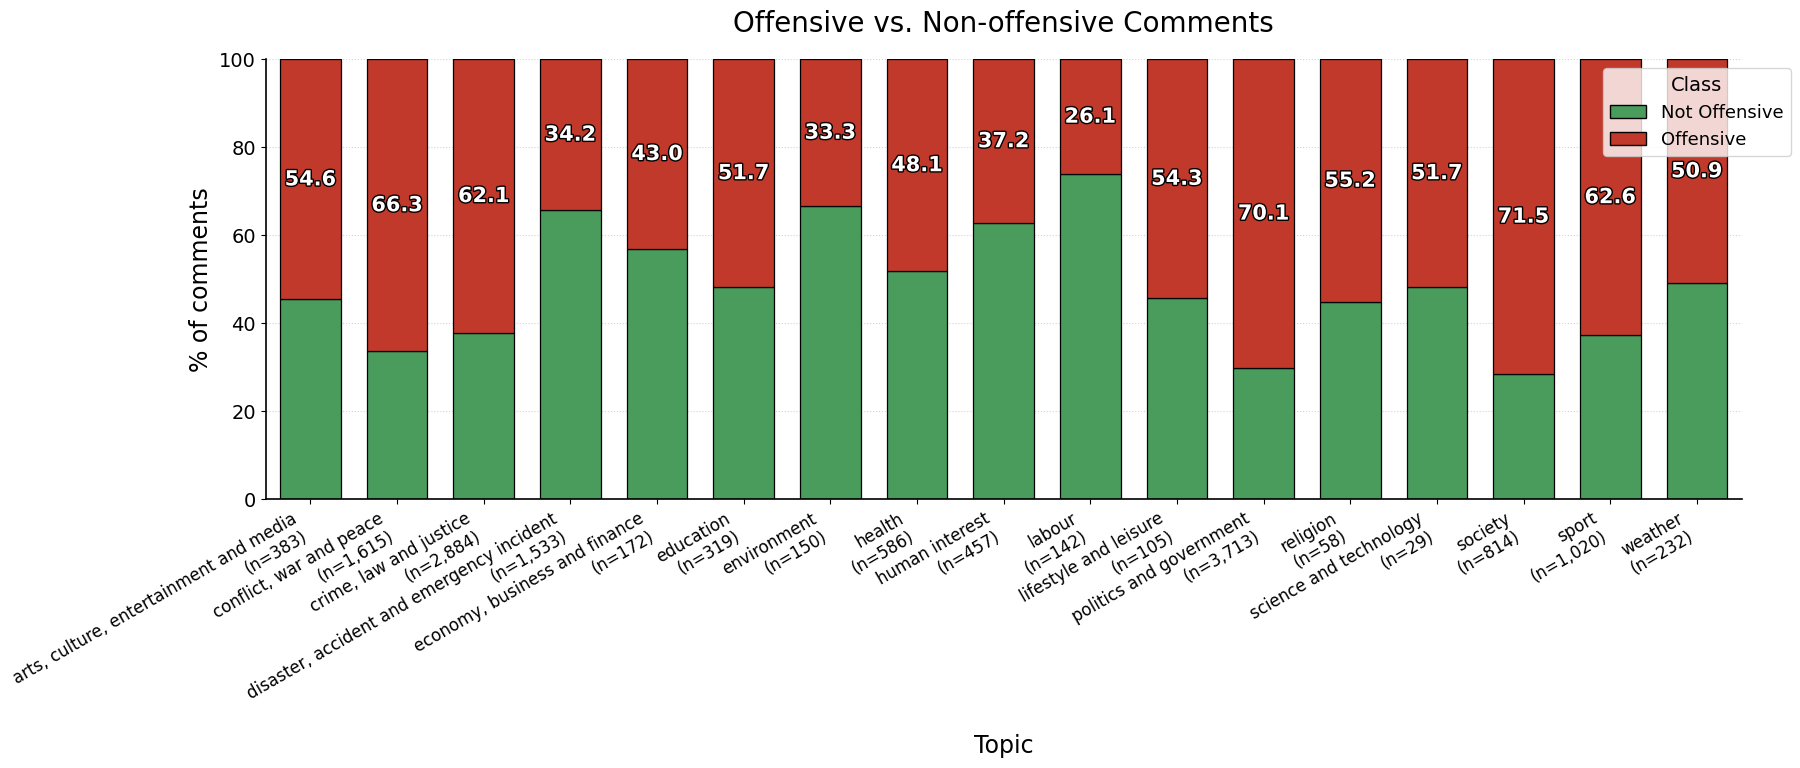

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

# ----------------------------------------------------------------------
# Global style
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.size":             15,
    "axes.titlesize":        20,
    "axes.labelsize":        17,
    "xtick.labelsize":       12,
    "ytick.labelsize":       14,
    "legend.fontsize":       13,
    "legend.title_fontsize": 14,
    "axes.linewidth":        1.2,
    "hatch.linewidth":       0.6,
    "font.family":           "DejaVu Sans",
})

# ----------------------------------------------------------------------
# Colors
# ----------------------------------------------------------------------
COLOR_NON = "#4a9c5d"   # non-offensive
COLOR_OFF = "#c0392b"   # offensive

# ----------------------------------------------------------------------
# All topics (NO Total)
# ----------------------------------------------------------------------
topics = sorted(all_comments_df["topic"].dropna().unique())

total_plot = total_stats.reindex(topics)

# ----------------------------------------------------------------------
# Counts per topic for x-axis labels
# ----------------------------------------------------------------------
topic_counts = (
    all_comments_df.groupby("topic")
    .size()
    .reindex(topics)
)

xtick_labels = [
    f"{topic}\n(n={topic_counts.loc[topic]:,})"
    for topic in topics
]

# ----------------------------------------------------------------------
# Figure
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

x = np.arange(len(topics))
width = 0.70

non_off = total_plot["non_offensive"].fillna(0)
off = total_plot["offensive"].fillna(0)

# ----------------------------------------------------------------------
# Bars
# ----------------------------------------------------------------------
ax.bar(
    x,
    non_off,
    width=width,
    color=COLOR_NON,
    edgecolor="black",
    linewidth=0.9,
    #hatch="\\"
)

ax.bar(
    x,
    off,
    width=width,
    bottom=non_off,
    color=COLOR_OFF,
    edgecolor="black",
    linewidth=0.9,
    #hatch="//"
)

# ----------------------------------------------------------------------
# Labels inside offensive segment
# ----------------------------------------------------------------------
label_fx = [pe.withStroke(linewidth=2.0, foreground="black")]

for i, val in enumerate(off):
    if pd.notna(val) and val >= 4:
        ax.text(
            x[i],
            non_off.iloc[i] + val / 2,
            f"{val:.1f}",
            ha="center",
            va="center",
            color="white",
            fontsize=15,
            fontweight="bold",
            path_effects=label_fx,
        )

# ----------------------------------------------------------------------
# Axes
# ----------------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(
    xtick_labels,
    rotation=30,
    ha="right"
)

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.set_ylabel("% of comments")
ax.set_xlabel("Topic", labelpad=10)
ax.set_title("Offensive vs. Non-offensive Comments", pad=20)

ax.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.55)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.01)

# ----------------------------------------------------------------------
# Legend
# ----------------------------------------------------------------------
class_handles = [
    Patch(
        facecolor=COLOR_NON,
        edgecolor="black",
        #hatch="\\",
        label="Not Offensive"
    ),
    Patch(
        facecolor=COLOR_OFF,
        edgecolor="black",
        #hatch="//",
        label="Offensive"
    ),
]

ax.legend(
    handles=class_handles,
    title="Class",
    loc="upper left",
    bbox_to_anchor=(0.90, 1.00),
    frameon=True
)

# ----------------------------------------------------------------------
# Layout & Save
# ----------------------------------------------------------------------
fig.subplots_adjust(
    left=0.06,
    right=0.88,
    top=0.90,
    bottom=0.35  # slightly larger to fit counts under labels
)

fig.savefig(
    "offensive_by_topic.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "offensive_by_topic.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

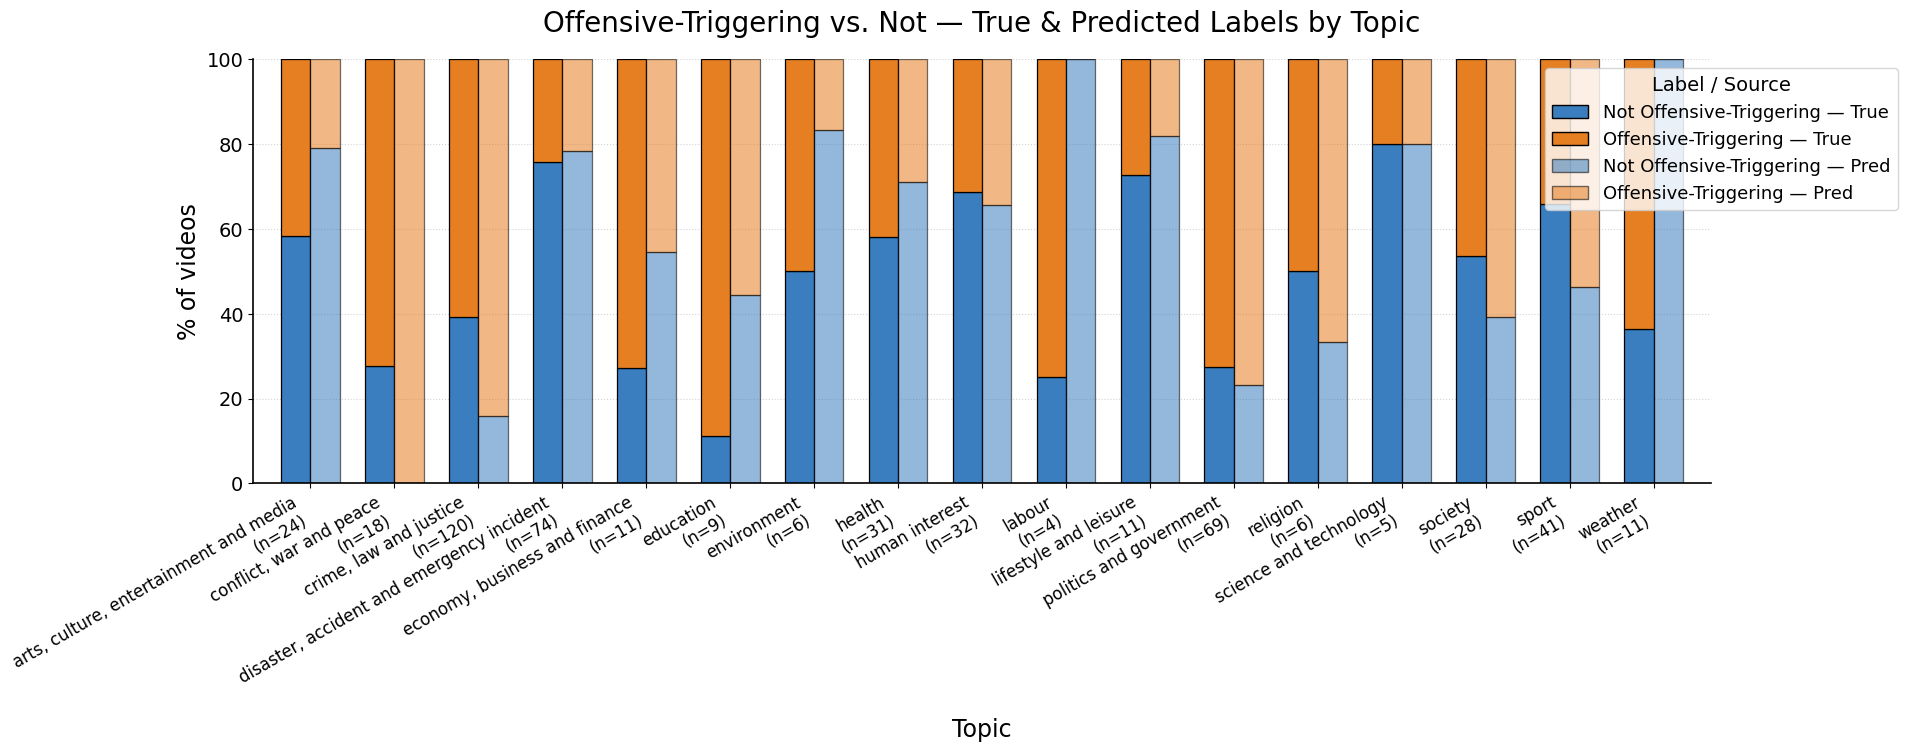

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ----------------------------------------------------------------------
# Global style
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.size":             15,
    "axes.titlesize":        20,
    "axes.labelsize":        17,
    "xtick.labelsize":       12,
    "ytick.labelsize":       14,
    "legend.fontsize":       13,
    "legend.title_fontsize": 14,
    "axes.linewidth":        1.2,
    "hatch.linewidth":       0.6,
    "font.family":           "DejaVu Sans",
})

# ----------------------------------------------------------------------
# Colors — distinct palette from the comments chart
# ----------------------------------------------------------------------
COLOR_NOT_TRIG = "#3a7ebf"   # label 0 — not offensive-triggering (blue)
COLOR_TRIG     = "#e67e22"   # label 1 — offensive-triggering (orange)

# ----------------------------------------------------------------------
# Load & aggregate
# ----------------------------------------------------------------------
df = pd.read_csv("results/gemma2/prompt_0.csv")

topics = sorted(df["video_topic"].dropna().unique())

# ----------------------------------------------------------------------
# Video counts per topic (for x-axis labels)
# ----------------------------------------------------------------------
topic_counts = (
    df.groupby("video_topic")
      .size()
      .reindex(topics)
)

xtick_labels = [
    f"{topic}\n(n={topic_counts.loc[topic]:,})"
    for topic in topics
]

def label_pcts(df, col):
    counts = df.groupby("video_topic")[col].value_counts().unstack(fill_value=0)
    counts = counts.reindex(topics, fill_value=0)

    for v in [0, 1]:
        if v not in counts.columns:
            counts[v] = 0

    totals = counts.sum(axis=1)
    pct = counts.div(totals, axis=0) * 100

    return pct[0], pct[1]   # not-triggering %, triggering %

true_not, true_trig = label_pcts(df, "true_label")
pred_not, pred_trig = label_pcts(df, "pred_label")

# ----------------------------------------------------------------------
# Figure
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 8))

x = np.arange(len(topics))
width = 0.35

x_true = x - width / 2
x_pred = x + width / 2

# ----------------------------------------------------------------------
# True label bars (solid)
# ----------------------------------------------------------------------
ax.bar(
    x_true,
    true_not,
    width=width,
    color=COLOR_NOT_TRIG,
    edgecolor="black",
    linewidth=0.9,
)

ax.bar(
    x_true,
    true_trig,
    width=width,
    bottom=true_not,
    color=COLOR_TRIG,
    edgecolor="black",
    linewidth=0.9,
)

# ----------------------------------------------------------------------
# Predicted label bars (faded)
# ----------------------------------------------------------------------
ax.bar(
    x_pred,
    pred_not,
    width=width,
    color=COLOR_NOT_TRIG,
    edgecolor="black",
    linewidth=0.9,
    alpha=0.55,
)

ax.bar(
    x_pred,
    pred_trig,
    width=width,
    bottom=pred_not,
    color=COLOR_TRIG,
    edgecolor="black",
    linewidth=0.9,
    alpha=0.55,
)

# ----------------------------------------------------------------------
# Axes
# ----------------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(
    xtick_labels,
    rotation=30,
    ha="right"
)

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 20))
ax.set_ylabel("% of videos")
ax.set_xlabel("Topic", labelpad=10)

ax.set_title(
    "Offensive-Triggering vs. Not — True & Predicted Labels by Topic",
    pad=20
)

ax.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.55)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.margins(x=0.02)

# ----------------------------------------------------------------------
# Legend
# ----------------------------------------------------------------------
legend_handles = [
    Patch(
        facecolor=COLOR_NOT_TRIG,
        edgecolor="black",
        label="Not Offensive-Triggering — True",
        alpha=1.0,
    ),
    Patch(
        facecolor=COLOR_TRIG,
        edgecolor="black",
        label="Offensive-Triggering — True",
        alpha=1.0,
    ),
    Patch(
        facecolor=COLOR_NOT_TRIG,
        edgecolor="black",
        label="Not Offensive-Triggering — Pred",
        alpha=0.55,
    ),
    Patch(
        facecolor=COLOR_TRIG,
        edgecolor="black",
        label="Offensive-Triggering — Pred",
        alpha=0.55,
    ),
]

ax.legend(
    handles=legend_handles,
    title="Label / Source",
    loc="upper left",
    bbox_to_anchor=(0.88, 1.00),
    frameon=True
)

# ----------------------------------------------------------------------
# Layout & save
# ----------------------------------------------------------------------
fig.subplots_adjust(
    left=0.06,
    right=0.87,
    top=0.88,
    bottom=0.35
)

fig.savefig(
    "true_vs_pred_by_topic.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "true_vs_pred_by_topic.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

### Visualizations at the video level

In [10]:
import pandas as pd
df_video = pd.read_csv("video_dataset.csv")

In [11]:
df_video

,video_id,newspaper,video_text,video_description,video_topic,num_comments,num_offensive_comments,offensive_score,offensive_trigger,type
0,-Jz16gcNDG4,corriere_della_sera,"Monza, lascia in eredità 570mila euro (e una c...",La signora era deceduta nel 2019 a 93 anni nel...,human interest,20,3,0.5701,0,gold
1,-vjNeffdABU,corriere_della_sera,Genova-Milano in treno in 55 minuti dal 2030: ...,Nuovo passo avanti per il Terzo Valico dei Gio...,science and technology,2,1,0.2952,0,silver
2,019ku18Adko,corriere_della_sera,"Addio a Renato Romagnoli, il partigiano “Itali...","Finché ha potuto, Renato “Italiano” Romagnoli ...",society,4,2,0.5559,0,silver
3,06P2sBlAqf8,corriere_della_sera,"Abbiamo provato Gemini Omni, nuovo modello Goo...","Google ha appena lanciato Gemini Omni, il suo ...",science and technology,1,1,0.5000,0,silver
4,0XkW6iFCmuw,corriere_della_sera,Il sindaco di Modena: “L’uomo è stato fermato ...,«Le indagini sono in corso da parte della Proc...,"crime, law and justice",65,48,0.8640,1,silver
...,...,...,...,...,...,...,...,...,...,...
495,yxhSFzAMWCY,repubblica,A Napoli un padre accoltella il figlio dodicen...,"Un litigio improvviso in casa, poi il dramma f...","crime, law and justice",24,12,0.7942,1,silver
496,yyooDzr0s8I,repubblica,"Grossman: ""Ben-Gvir una disgrazia nazionale, n...","""Gente come Ben-Gvir, quello che lui aizza non...",politics and government,196,132,0.8866,1,silver
497,zO2XylesnrE,repubblica,"Meloni: ""Vogliamo proseguire sulla strada per ...","""La principale enorme fragilità che ci riguard...",politics and government,120,61,0.8643,1,silver
498,zSDdaX_apcQ,repubblica,"Le 50 spiagge più belle del mondo: Filippine, ...","Calette nascoste da alte scogliere, lunghe lin...",lifestyle and leisure,7,1,0.0903,0,silver


/tmp/ipykernel_214305/2790813119.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(tick)}%" for tick in ax.get_yticks()], fontsize=14)


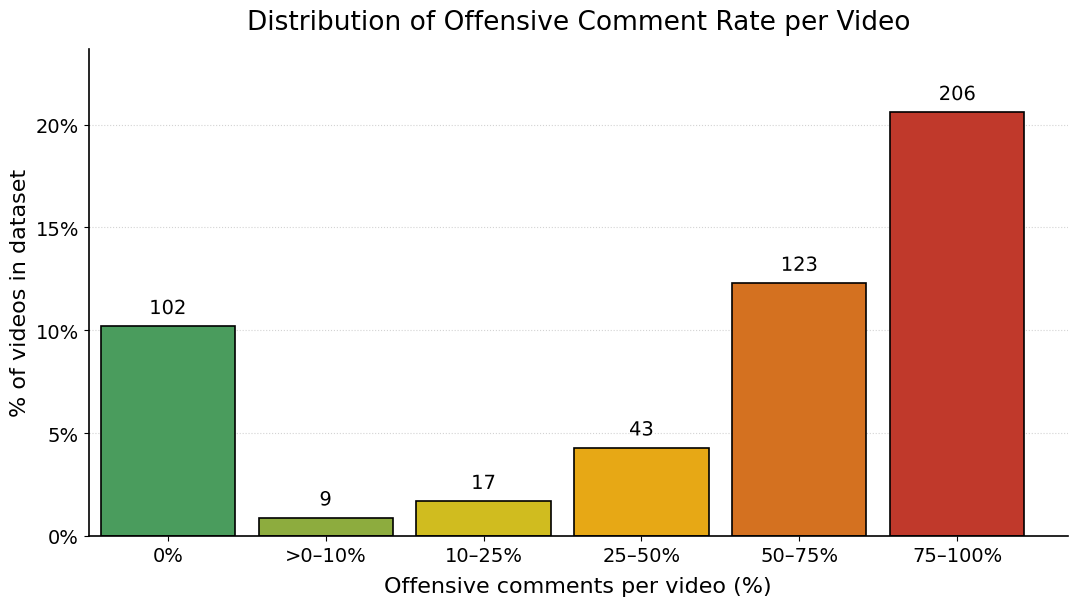

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors

# ----------------------------------------------------------------------
# Style
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 19,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.linewidth": 1.2,
    "hatch.linewidth": 0.6,
    "font.family": "DejaVu Sans",
})

# ----------------------------------------------------------------------
# Distribution helper
# ----------------------------------------------------------------------
def get_video_distribution(df):
    off_rate = df["offensive_score"] * 100
    counts = {"0%": int((off_rate == 0).sum())}
    positive = off_rate[off_rate > 0]

    bins = [
        (">0–10%",   0.0001, 10),
        ("10–25%",  10, 25),
        ("25–50%",  25, 50),
        ("50–75%",  50, 75),
        ("75–100%", 75, 100),
    ]

    for label, low, high in bins:
        counts[label] = int(((positive > low) & (positive <= high)).sum())

    return pd.Series(counts)

# ----------------------------------------------------------------------
# DATA
# ----------------------------------------------------------------------
dist = get_video_distribution(df_video)
total_n = dist.sum()
pct = dist / total_n * 100

# ----------------------------------------------------------------------
# FIGURE
# ----------------------------------------------------------------------
# Ridotto leggermente il figsize da (14, 7) a (11, 6.5) per compattare l'orizzontale
fig, ax = plt.subplots(figsize=(11, 6.5))

bins = dist.index
x = np.arange(len(bins))

# ----------------------------------------------------------------------
# SEVERITY GRADIENT (From custom Green to Red)
# ----------------------------------------------------------------------
cmap_face = mcolors.LinearSegmentedColormap.from_list("gradient_face", ["#4a9c5d", "#f1c40f", "#c0392b"], N=len(bins))
cmap_edge = mcolors.LinearSegmentedColormap.from_list("gradient_edge", ["#346e41", "#b7950b", "#922b21"], N=len(bins))

colors = [mcolors.to_hex(cmap_face(i)) for i in range(len(bins))]
edge_colors = [mcolors.to_hex(cmap_edge(i)) for i in range(len(bins))]

# ----------------------------------------------------------------------
# BARS
# ----------------------------------------------------------------------
bars = ax.bar(
    x,
    pct.values,
    width=0.85,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# ----------------------------------------------------------------------
# ANNOTATIONS (raw counts)
# ----------------------------------------------------------------------
label_fx = [pe.withStroke(linewidth=1.8, foreground="white")]

for rect, raw in zip(bars, dist.values):
    if rect.get_height() > 0:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 0.8,
            f"{raw}",
            ha="center",
            va="bottom",
            fontsize=14, # Alzato leggermente per leggibilità
            path_effects=label_fx,
        )

# ----------------------------------------------------------------------
# AXES & FORMATTING
# ----------------------------------------------------------------------
# Spostata la linea tratteggiata per allinearsi perfettamente allo spazio tra prima e seconda barra
# ax.axvline(x=0.5, linestyle="--", color="black", linewidth=1.4, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(bins, fontsize=14)
ax.set_yticklabels([f"{int(tick)}%" for tick in ax.get_yticks()], fontsize=14)

ax.set_xlabel("Offensive comments per video (%)", labelpad=8)
ax.set_ylabel("% of videos in dataset")
ax.set_title("Distribution of Offensive Comment Rate per Video", pad=14)

ax.set_ylim(0, pct.max() * 1.15)
ax.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.55)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

# Aggiunto un minimo di margine laterale per non far toccare le barre esterne ai bordi del grafico
ax.set_xlim(-0.5, len(bins) - 0.3)

# ----------------------------------------------------------------------
# SAVE + SHOW
# ----------------------------------------------------------------------
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.13)

fig.savefig("video_offrate_dist.pdf", bbox_inches="tight")
fig.savefig("video_offrate_dist.png", bbox_inches="tight", dpi=300)

plt.show()

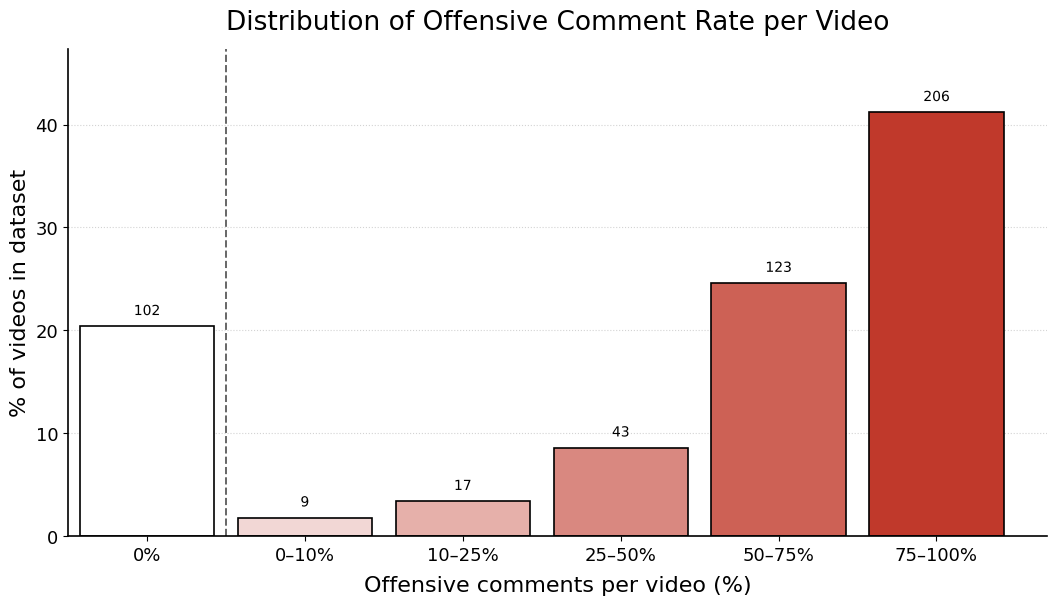

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors

# ----------------------------------------------------------------------
# Style
# ----------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 19,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.linewidth": 1.2,
    "hatch.linewidth": 0.6,
    "font.family": "DejaVu Sans",
})

# ----------------------------------------------------------------------
# Distribution helper
# ----------------------------------------------------------------------
def get_video_distribution(df):
    off_rate = df["offensive_score"] * 100
    counts = {"0%": int((off_rate == 0).sum())}
    positive = off_rate[off_rate > 0]

    bins = [
        ("0–10%",   0.0001, 10),
        ("10–25%",  10, 25),
        ("25–50%",  25, 50),
        ("50–75%",  50, 75),
        ("75–100%", 75, 100),
    ]

    for label, low, high in bins:
        counts[label] = int(((positive > low) & (positive <= high)).sum())

    return pd.Series(counts)

# ----------------------------------------------------------------------
# DATA
# ----------------------------------------------------------------------
dist = get_video_distribution(df_video)
total_n = dist.sum()
pct = dist / total_n * 100

# ----------------------------------------------------------------------
# FIGURE
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6.5))

bins = dist.index
x = np.arange(len(bins))

# ----------------------------------------------------------------------
# SEVERITY GRADIENT (From White to Red)
# ----------------------------------------------------------------------

cmap_face = mcolors.LinearSegmentedColormap.from_list("white_to_red", ["#ffffff", "#c0392b"], N=len(bins))
colors = [mcolors.to_hex(cmap_face(i)) for i in range(len(bins))]

# ----------------------------------------------------------------------
# BARS
# ----------------------------------------------------------------------
bars = ax.bar(
    x,
    pct.values,
    width=0.85,
    color=colors,
    edgecolor="black",
    linewidth=1.2
)

# ----------------------------------------------------------------------
# ANNOTATIONS (raw counts)
# ----------------------------------------------------------------------
label_fx = [pe.withStroke(linewidth=1.8, foreground="white")]

for rect, raw in zip(bars, dist.values):
    if rect.get_height() > 0:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 0.8,
            f"{raw}",
            ha="center",
            va="bottom",
            fontsize=10,
            path_effects=label_fx,
        )

# ----------------------------------------------------------------------
# AXES & FORMATTING
# ----------------------------------------------------------------------
ax.axvline(x=0.5, linestyle="--", color="black", linewidth=1.4, alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(bins)

ax.set_xlabel("Offensive comments per video (%)", labelpad=8)
ax.set_ylabel("% of videos in dataset")
ax.set_title("Distribution of Offensive Comment Rate per Video", pad=14)

ax.set_ylim(0, pct.max() * 1.15)
ax.yaxis.grid(True, linestyle=":", linewidth=0.8, alpha=0.55)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

ax.set_xlim(-0.5, len(bins) - 0.3)

# ----------------------------------------------------------------------
# SAVE + SHOW
# ----------------------------------------------------------------------
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.13)

fig.savefig("video_offrate_dist.pdf", bbox_inches="tight")
fig.savefig("video_offrate_dist.png", bbox_inches="tight", dpi=300)

plt.show()

- - -
### Visualizations of the metric
Careful cause entries w.o. comments are not visualized here.

In [16]:
df_video

,video_id,newspaper,video_text,video_description,video_topic,num_comments,num_offensive_comments,offensive_score,offensive_trigger,type
0,-Jz16gcNDG4,corriere_della_sera,"Monza, lascia in eredità 570mila euro (e una c...",La signora era deceduta nel 2019 a 93 anni nel...,human interest,20,3,0.5701,0,gold
1,-vjNeffdABU,corriere_della_sera,Genova-Milano in treno in 55 minuti dal 2030: ...,Nuovo passo avanti per il Terzo Valico dei Gio...,science and technology,2,1,0.2952,0,silver
2,019ku18Adko,corriere_della_sera,"Addio a Renato Romagnoli, il partigiano “Itali...","Finché ha potuto, Renato “Italiano” Romagnoli ...",society,4,2,0.5559,0,silver
3,06P2sBlAqf8,corriere_della_sera,"Abbiamo provato Gemini Omni, nuovo modello Goo...","Google ha appena lanciato Gemini Omni, il suo ...",science and technology,1,1,0.5000,0,silver
4,0XkW6iFCmuw,corriere_della_sera,Il sindaco di Modena: “L’uomo è stato fermato ...,«Le indagini sono in corso da parte della Proc...,"crime, law and justice",65,48,0.8640,1,silver
...,...,...,...,...,...,...,...,...,...,...
495,yxhSFzAMWCY,repubblica,A Napoli un padre accoltella il figlio dodicen...,"Un litigio improvviso in casa, poi il dramma f...","crime, law and justice",24,12,0.7942,1,silver
496,yyooDzr0s8I,repubblica,"Grossman: ""Ben-Gvir una disgrazia nazionale, n...","""Gente come Ben-Gvir, quello che lui aizza non...",politics and government,196,132,0.8866,1,silver
497,zO2XylesnrE,repubblica,"Meloni: ""Vogliamo proseguire sulla strada per ...","""La principale enorme fragilità che ci riguard...",politics and government,120,61,0.8643,1,silver
498,zSDdaX_apcQ,repubblica,"Le 50 spiagge più belle del mondo: Filippine, ...","Calette nascoste da alte scogliere, lunghe lin...",lifestyle and leisure,7,1,0.0903,0,silver


In [17]:
df_video[df_video["num_offensive_comments"] == 0]['num_offensive_comments']

,num_offensive_comments
5,0
10,0
11,0
15,0
36,0
...,...
393,0
395,0
445,0
467,0


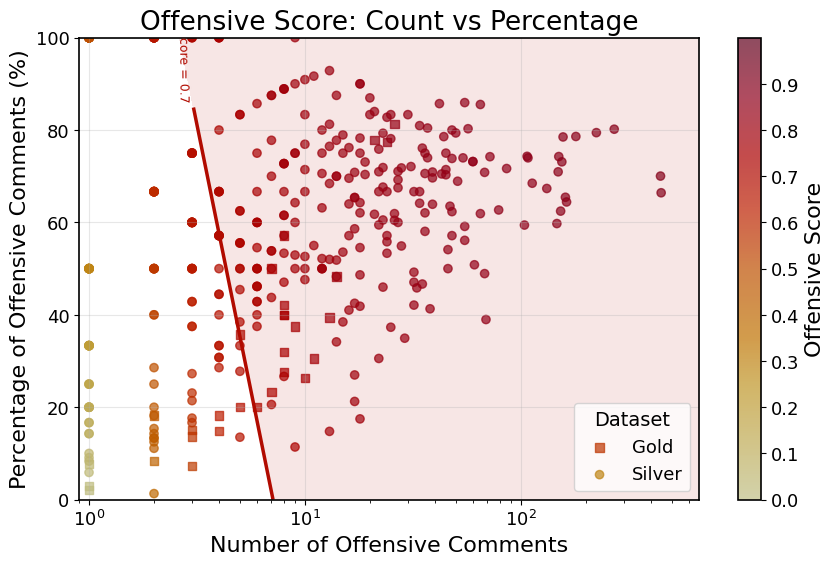

In [37]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import colorsys

def offensive_score(n, n_off, lambda1=1.0):
    if n == 0 or n_off == 0:
        return 0.0
    return np.arctan((n_off / n) + lambda1 * np.log(n_off)) / (np.pi / 2)

# ------------------------------------------------------------------
# Custom colormap:
# ------------------------------------------------------------------
base_cmap = plt.get_cmap("YlOrRd")
colors = base_cmap(np.linspace(0, 1, 256))

for i, c in enumerate(colors):
    h, s, v = colorsys.rgb_to_hsv(c[0], c[1], c[2])
    s = min(1.0, s * 1.5)
    v = min(1.0, v * 0.75)
    r, g, b = colorsys.hsv_to_rgb(h, s, v)
    colors[i] = (r, g, b, c[3])

custom_cmap = mcolors.LinearSegmentedColormap.from_list("YlOrRd_vivid", colors)

# ------------------------------------------------------------------
# Copy and compute percentage
# ------------------------------------------------------------------
plot_df = df_video.copy()
plot_df["offensive_pct"] = (
    plot_df["num_offensive_comments"] /
    plot_df["num_comments"].replace(0, np.nan)
) * 100

lambda1 = 1.0

# ------------------------------------------------------------------
# Griglia per curva di livello
# ------------------------------------------------------------------
n_off_grid = np.logspace(0, np.log10(plot_df["num_offensive_comments"].max() * 1.5), 1000)
pct_grid   = np.linspace(0, 100, 1000)
N_OFF, PCT = np.meshgrid(n_off_grid, pct_grid)

SCORE = np.arctan(PCT / 100 + lambda1 * np.log(N_OFF)) / (np.pi / 2)

fig, ax = plt.subplots(figsize=(10, 6))

gold = plot_df[plot_df["type"].str.lower() == "gold"]
sc_gold = ax.scatter(
    gold["num_offensive_comments"], gold["offensive_pct"],
    c=gold["offensive_score"], cmap=custom_cmap, vmin=0, vmax=1,
    alpha=0.7, marker="s", label="Gold"
)

silver = plot_df[plot_df["type"].str.lower() == "silver"]
ax.scatter(
    silver["num_offensive_comments"], silver["offensive_pct"],
    c=silver["offensive_score"], cmap=custom_cmap, vmin=0, vmax=1,
    alpha=0.7, marker="o", label="Silver"
)

color_07 = custom_cmap(0.7)

contour = ax.contour(N_OFF, PCT, SCORE, levels=[0.7], colors=[color_07], linewidths=2.5)
ax.clabel(contour, fmt={0.7: "OffScore = 0.7"}, fontsize=9, inline=True)
ax.contourf(N_OFF, PCT, SCORE, levels=[0.7, 1.0], colors=[color_07], alpha=0.10)

ax.set_xscale("log")
ax.set_xlim(left=0.9)
ax.set_ylim(0, 100)
ax.set_xlabel("Number of Offensive Comments")
ax.set_ylabel("Percentage of Offensive Comments (%)")
ax.set_title("Offensive Score: Count vs Percentage")

cb = plt.colorbar(sc_gold, ax=ax, label="Offensive Score")
cb.set_ticks(np.arange(0.0, 1.0, 0.1))
cb.set_ticklabels([f"{x:.1f}" for x in np.arange(0.0, 1.0, 0.1)])
ax.legend(title="Dataset")
ax.grid(True, alpha=0.3)

plt.savefig("offensive_score.png", bbox_inches="tight", dpi=300)
plt.show()